In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages

d:\agenticai\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")
llm.invoke("Hi")

AIMessage(content='Hey there! What’s on your mind today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We should respond in a friendly manner. The instruction says we should ask the user for the topic they\'d like to talk about. We should be concise, and not mention the policies. The user hasn\'t asked a question, so we should prompt. The instruction says to ask the user what they\'d like to talk about. Let\'s do that.'}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 72, 'total_tokens': 164, 'completion_time': 0.17271233, 'completion_tokens_details': {'reasoning_tokens': 73}, 'prompt_time': 0.003912883, 'prompt_tokens_details': None, 'queue_time': 0.046924664, 'total_time': 0.176625213}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f18a1-c9bd-7240-98cf-f9ccd82327d7-0', tool_calls=[], invalid_tool_

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def bot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

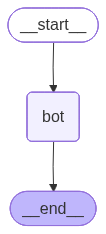

In [9]:
graph = StateGraph(State)

graph.add_node("bot", bot)

graph.add_edge(START,"bot")
graph.add_edge("bot",END)

build = graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(build.get_graph().draw_mermaid_png()))

In [14]:
config = {"configurable":{"thread_id":"a"}}
messages = build.invoke({"messages":"Hello!! How are you?"},config=config)
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hello!! How are you?
================================== Ai Message ==================================

Hello! 🌞 I’m doing great—thanks for asking! How about you? Anything interesting happening in your world today?


In [17]:
config1 = {"configurable":{"thread_id":"2"}}

for chunk in build.stream({"messages":"Hello! I am Bix and I like mythology"},config=config1, stream_mode='updates'):
    print(chunk)

{'bot': {'messages': [AIMessage(content='Hello Bix! 👋 It’s great to meet another mythology fan. 🌌\n\nWhat kind of myths tug at your curiosity? Are you into the epic tales of Greek gods, the rich folklore of Norse sagas, ancient Egyptian lore, or perhaps the legends from your own culture? I’m all ears (or rather, all text) and ready to dive into stories, symbols, or even modern retellings with you. Let me know what sparks your interest!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hello! I am Bix and I like mythology". We should respond in a friendly tone, maybe ask what kind of mythology they like, or share something. We should be concise but engaging.'}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 81, 'total_tokens': 238, 'completion_time': 0.277705997, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.004656488, 'prompt_tokens_details': None, 'queue_time': 0.532970037, 'total_time': 0.

In [ ]:
config1 = {"configurable":{"thread_id":"2"}}

for chunk in build.stream({"messages":"Hello! I am Bix and I like mythology"},config=config1, stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hello! I am Bix and I like mythology', additional_kwargs={}, response_metadata={}, id='abe81518-ca86-45fa-88d4-7cb58437ca62')]}
{'messages': [HumanMessage(content='Hello! I am Bix and I like mythology', additional_kwargs={}, response_metadata={}, id='abe81518-ca86-45fa-88d4-7cb58437ca62'), AIMessage(content='Hey Bix! 👋 Great to meet a fellow mythology enthusiast. 🌟\n\nWhat kind of myths do you find most fascinating? Are you into the epic tales of the Greeks, the rich folklore of Norse legends, the mystic stories from East Asia, or something else entirely? If you have a favorite myth or a particular hero, deity, or creature you love, let me know—I’d love to dive into it with you!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hello! I am Bix and I like mythology". They likely want a conversation about mythology. We can greet, ask what mythologies they\'re interested in, or share interesting facts. There\'s no special ins

In [20]:
config1 = {"configurable":{"thread_id":"2"}}

for chunk in build.stream({"messages":"I also like cricket"},config=config1, stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hello! I am Bix and I like mythology', additional_kwargs={}, response_metadata={}, id='c935645b-f3ba-42b6-b496-4616242fae56'), AIMessage(content='Hello Bix! 👋 It’s great to meet another mythology fan. 🌌\n\nWhat kind of myths tug at your curiosity? Are you into the epic tales of Greek gods, the rich folklore of Norse sagas, ancient Egyptian lore, or perhaps the legends from your own culture? I’m all ears (or rather, all text) and ready to dive into stories, symbols, or even modern retellings with you. Let me know what sparks your interest!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hello! I am Bix and I like mythology". We should respond in a friendly tone, maybe ask what kind of mythology they like, or share something. We should be concise but engaging.'}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 81, 'total_tokens': 238, 'completion_time': 0.277705997, 'completion_toke

In [21]:
config3 = {"configurable":{"thread_id":"3"}}

async for event in build.astream_events({"messages":"Hello. I like to play valorant."}, config=config3, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello. I like to play valorant.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f18d6-8260-71a3-a72d-d8237f36f906', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hello. I like to play valorant.', additional_kwargs={}, response_metadata={}, id='14f545e7-d1be-498d-9d6d-580102199460')]}}, 'name': 'bot', 'tags': ['graph:step:1'], 'run_id': '019f18d6-826c-7ee3-9b3a-1edfd69cd862', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'bot', 'langgraph_triggers': ('branch:to:bot',), 'langgraph_path': ('__pregel_pull', 'bot'), 'langgraph_checkpoint_ns': 'bot:501d0168-1764-b483-7576-8337c2127fc3'}, 'parent_ids': ['019f18d6-8260-71a3-a72d-d8237f36f906']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hello. I like to play valorant.'